### This notebook is to describe the ambulance calls distribution across the 12 ambulance locations

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
print(os.getcwd())

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/src


In [3]:
# read the 3 csv files containing calls for George tow1n, 
# seberang perai (Penang mainland) and the 2 bridges (bridges are combined)

george_town_df = pd.read_csv("../datasets/penang_maps/penang_split/george_town_theoretical_calls.csv")
seberang_df = pd.read_csv("../datasets/penang_maps/penang_split/seberang_theoretical_calls.csv")
bridges_df = pd.read_csv("../datasets/penang_maps/penang_split/bridges_theoretical_calls.csv")

# combine them
df_all = pd.concat([george_town_df, seberang_df, bridges_df], ignore_index=True)
df_all

,id,day_of_week,hour_of_day,is_holiday,call_sign
0,2,2024-01-01 10:30:00,10,New Year,Penang 10
1,3,2024-01-01 10:38:00,10,New Year,SJ 9
2,4,2024-01-01 10:44:00,10,New Year,Penang 9 & 6
3,5,2024-01-01 10:45:00,10,New Year,Penang 9 & 6
4,8,2024-01-01 11:58:00,11,New Year,Penang 9 & 6
...,...,...,...,...,...
28396,27707,2024-09-27 06:57:00,6,Prophet Muhammad Birthday,Seberang
28397,28011,2024-03-09 07:40:00,7,Not Holiday,Penang 10
28398,28390,2024-06-09 06:39:00,6,Not Holiday,RC 6
28399,28459,2024-07-09 06:37:00,6,Not Holiday,Penang 10


In [4]:
print(df_all["day_of_week"].min())
print(df_all["day_of_week"].max())

2024-01-01 10:26:00
2024-12-31 23:15:00


In [11]:
df_all["day_of_week"] = pd.to_datetime(df_all["day_of_week"])
df_all["days_of_week"] = df_all["day_of_week"].dt.day_name()
df_all.rename(columns = {"call_sign":"assigned_call_sign"}, inplace = True)
df_all.rename(columns = {"day_of_week":"datetime"}, inplace = True)
df_all

,id,datetime,hour_of_day,is_holiday,assigned_call_sign,days_of_week
0,2,2024-01-01 10:30:00,10,New Year,Penang 10,Monday
1,3,2024-01-01 10:38:00,10,New Year,SJ 9,Monday
2,4,2024-01-01 10:44:00,10,New Year,Penang 9 & 6,Monday
3,5,2024-01-01 10:45:00,10,New Year,Penang 9 & 6,Monday
4,8,2024-01-01 11:58:00,11,New Year,Penang 9 & 6,Monday
...,...,...,...,...,...,...
28396,27707,2024-09-27 06:57:00,6,Prophet Muhammad Birthday,Seberang,Friday
28397,28011,2024-03-09 07:40:00,7,Not Holiday,Penang 10,Saturday
28398,28390,2024-06-09 06:39:00,6,Not Holiday,RC 6,Sunday
28399,28459,2024-07-09 06:37:00,6,Not Holiday,Penang 10,Tuesday


In [12]:
df_all.to_csv("../datasets/ambulance_total_calls.csv")
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28401 entries, 0 to 28400
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  28401 non-null  int64         
 1   datetime            28401 non-null  datetime64[ns]
 2   hour_of_day         28401 non-null  int64         
 3   is_holiday          28401 non-null  object        
 4   assigned_call_sign  28401 non-null  object        
 5   days_of_week        28401 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 1.3+ MB


#### Splitting calls by their assigned_call_signs

In [15]:
print(df_all["assigned_call_sign"].unique())

['Penang 10' 'SJ 9' 'Penang 9 & 6' 'Pulau 8' 'Penang 7 & 5' 'Pulau 4'
 'RC 6' 'Penang 8 & 1' 'BM' 'Seberang' 'Bakap' 'Batas']


In [ ]:
# List of all unique call signs
call_signs = [
    'Penang 10', 'SJ 9', 'Penang 9 & 6', 'Pulau 8', 'Penang 7 & 5',
    'Pulau 4', 'RC 6', 'Penang 8 & 1', 'BM', 'Seberang', 'Bakap', 'Batas'
]

# for sign in call_signs:
#     print(df_all[df_all["assigned_call_sign"] == sign].shape[0])

# Determine the call sign with the max number of calls
max_length = max(df_all[df_all["assigned_call_sign"] == sign].shape[0] for sign in call_signs)
# print(max_length)

# 3. Pad the shorter lists with NaN
padded_columns = {}

for i, sign in enumerate(call_signs):
    # Calculate how many NaNs are needed
    padding_needed = max_length - df_all[df_all["assigned_call_sign"] == sign].shape[0]
    df_filtered = df_all[df_all["assigned_call_sign"] == sign]["datetime"]

    padded_columns[sign] = df_filtered.reset_index(drop=True)

df_padded_datetimes = pd.concat(padded_columns, axis=1)

print(f"\nDataFrame shape: {df_padded_datetimes.shape}")
df_padded_datetimes.to_csv("../datasets/calls_by_callsign.csv")

2073
3085
3375
1099
570
2366
1947
913
4277
3415
2812
2469

DataFrame shape: (4277, 12)


In [122]:
calls_by_day = df_all.groupby(['assigned_call_sign', 'days_of_week']).size().reset_index(name='total_calls')
calls_by_hour = df_all.groupby(['assigned_call_sign', 'hour_of_day']).size().reset_index(name='total_calls')
print(calls_by_day)
print(calls_by_hour)

   assigned_call_sign days_of_week  total_calls
0                  BM       Friday          651
1                  BM       Monday          544
2                  BM     Saturday          658
3                  BM       Sunday          630
4                  BM     Thursday          635
..                ...          ...          ...
79           Seberang     Saturday          482
80           Seberang       Sunday          491
81           Seberang     Thursday          453
82           Seberang      Tuesday          509
83           Seberang    Wednesday          496

[84 rows x 3 columns]
    assigned_call_sign  hour_of_day  total_calls
0                   BM            0          117
1                   BM            1           80
2                   BM            2           86
3                   BM            3           46
4                   BM            4           75
..                 ...          ...          ...
283           Seberang           19          180
284      

#### Plot by total calls vs days of week

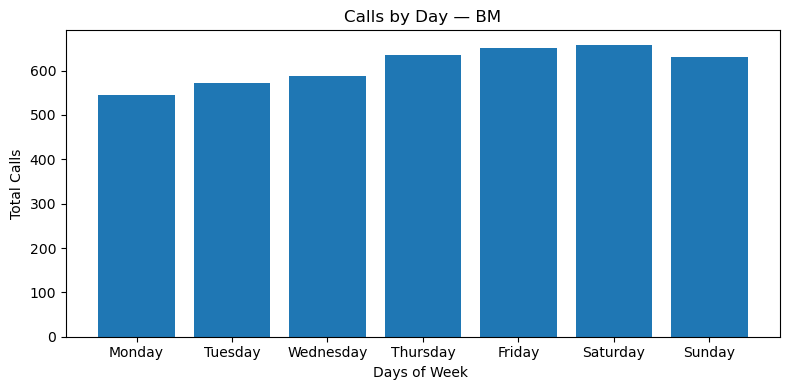

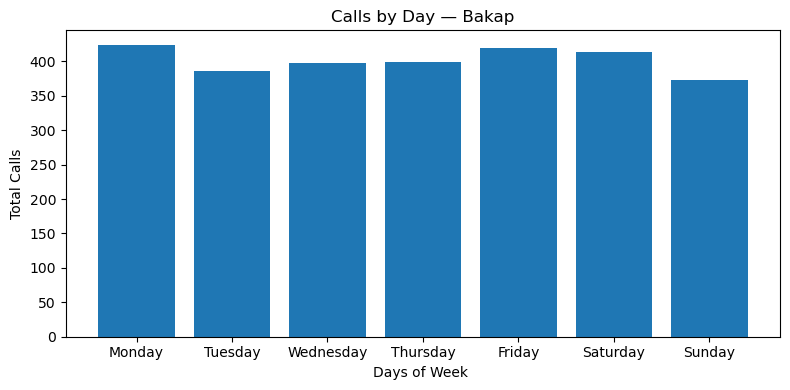

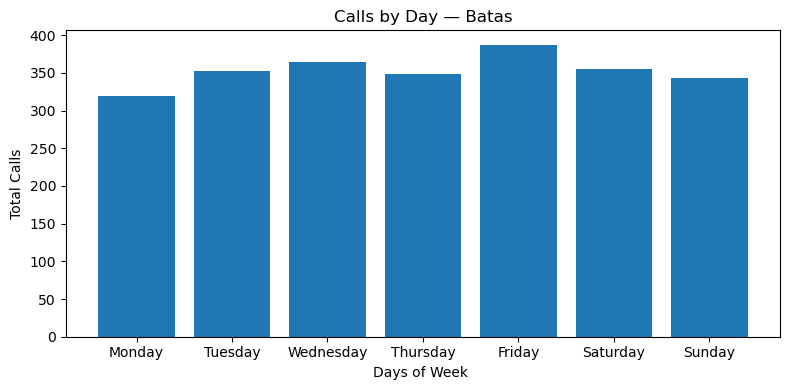

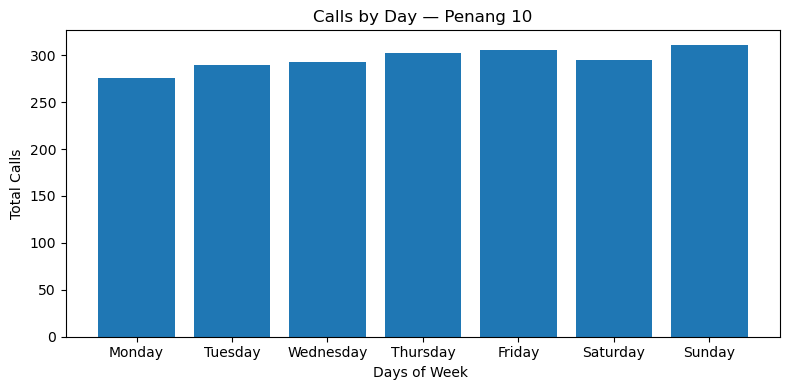

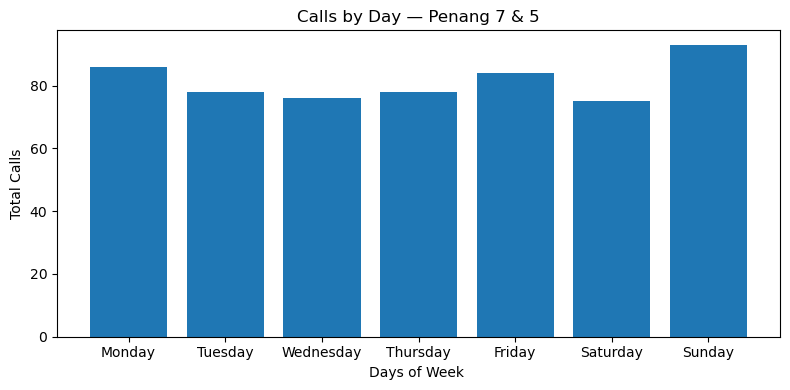

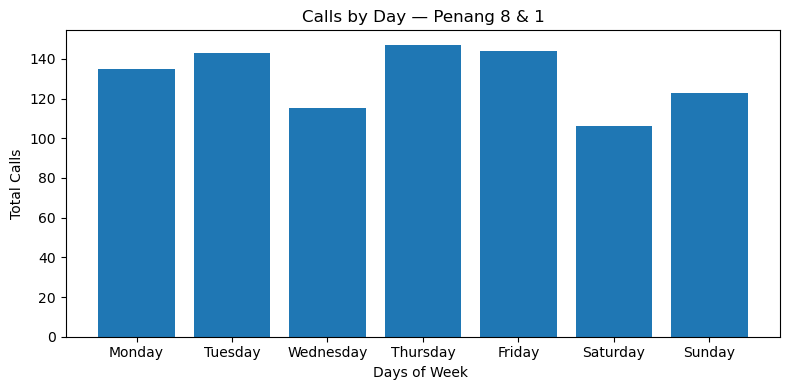

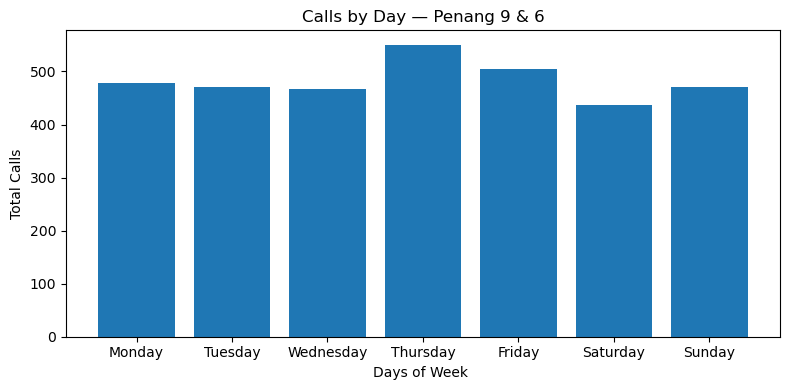

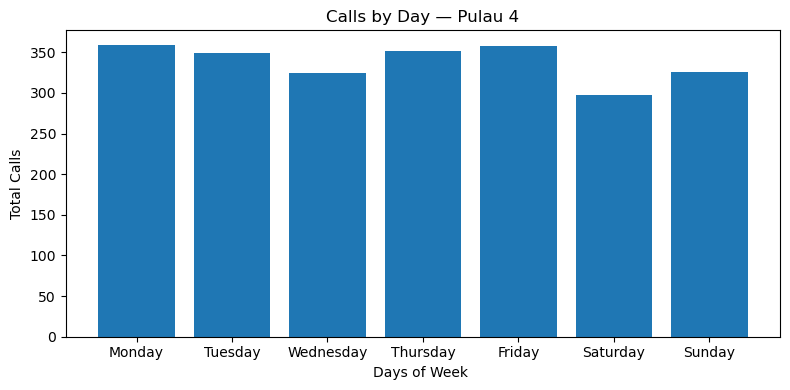

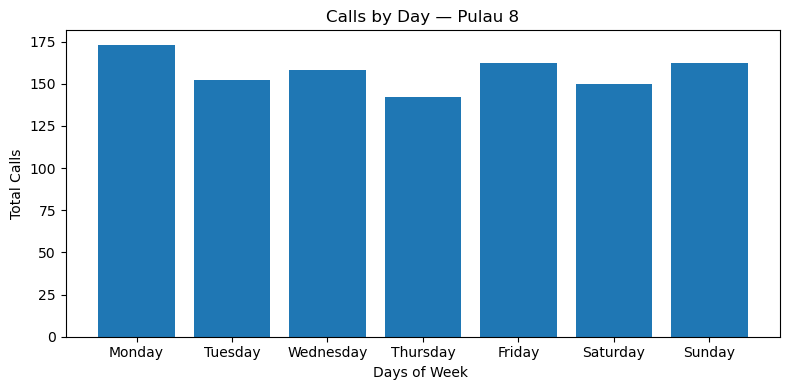

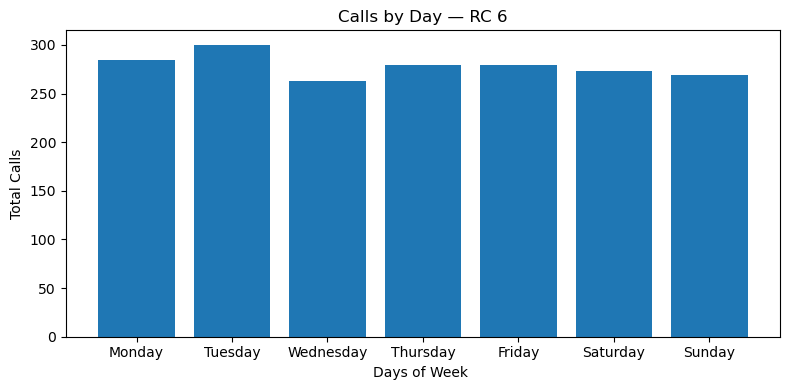

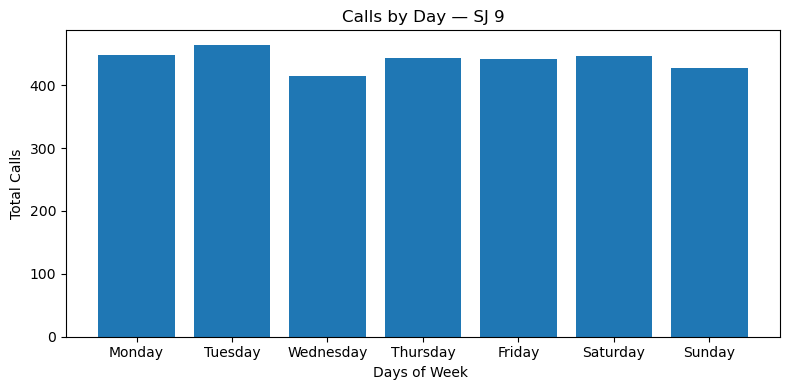

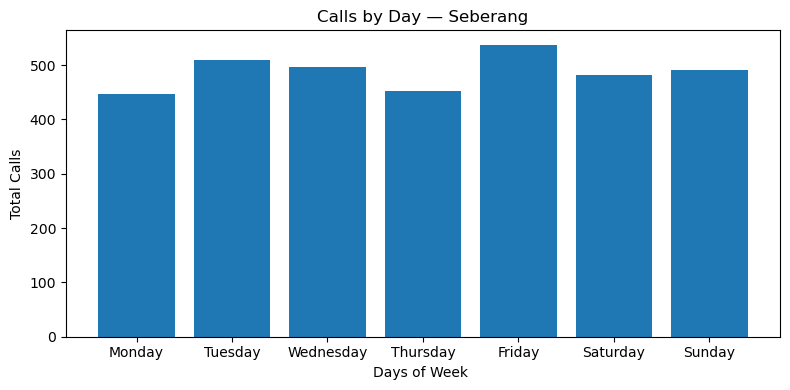

In [124]:
# set an order for the days of week
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

for call_sign, g in calls_by_day.groupby('assigned_call_sign'):
    g = (g.assign(days_of_week=pd.Categorical(g['days_of_week'], categories=order, ordered=True)).sort_values('days_of_week'))
    plt.figure(figsize=(8, 4))
    plt.bar(g['days_of_week'], g['total_calls'])
    plt.title(f'Calls by Day — {call_sign}')
    plt.xlabel('Days of Week ')
    plt.ylabel('Total Calls')
    # plt.xticks(range(0, 24))
    plt.tight_layout()
    # Show or save — pick one:
    plt.show()
    # plt.savefig(f'calls_by_hour_{call_sign}.png', dpi=150, bbox_inches='tight')
    plt.close()

### Displaying calls for days of week / by 52 weeks
Since the dataset records calls from Jan 1st 2024 to Dec 31st 2024

In [126]:
calls_by_day["calls_per_week"] = (calls_by_day["total_calls"] / 52)
print(calls_by_day)

   assigned_call_sign days_of_week  total_calls  calls_per_week
0                  BM       Friday          651       12.519231
1                  BM       Monday          544       10.461538
2                  BM     Saturday          658       12.653846
3                  BM       Sunday          630       12.115385
4                  BM     Thursday          635       12.211538
..                ...          ...          ...             ...
79           Seberang     Saturday          482        9.269231
80           Seberang       Sunday          491        9.442308
81           Seberang     Thursday          453        8.711538
82           Seberang      Tuesday          509        9.788462
83           Seberang    Wednesday          496        9.538462

[84 rows x 4 columns]


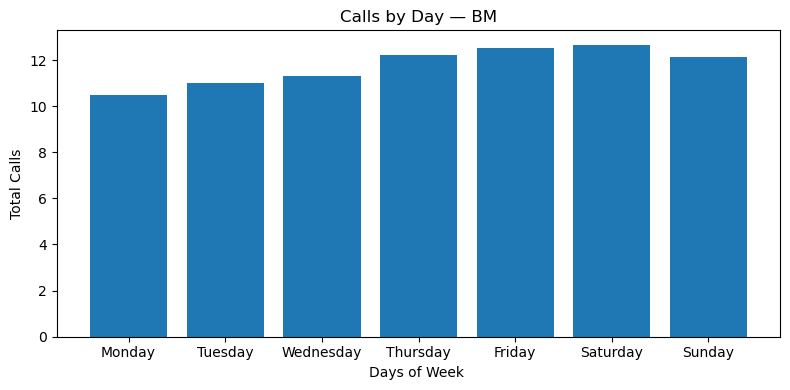

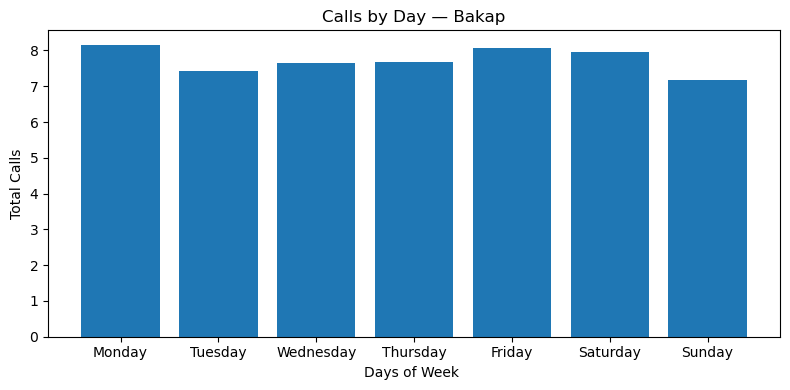

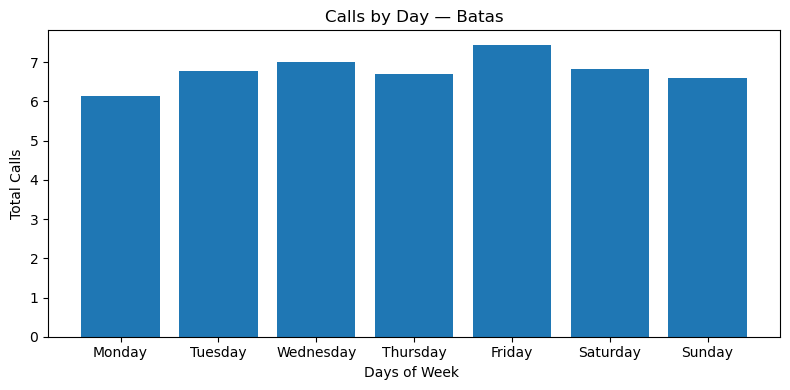

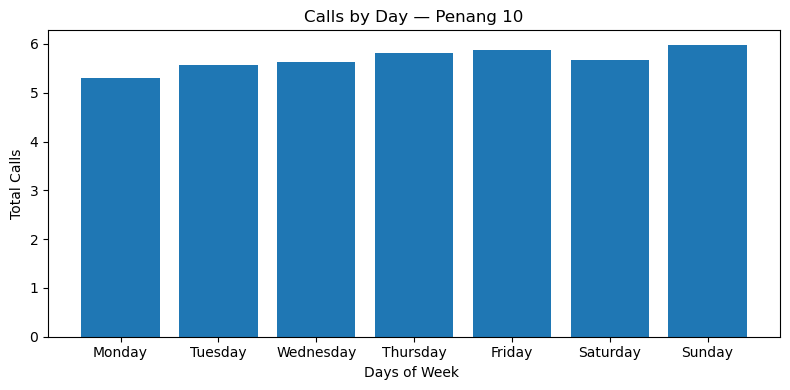

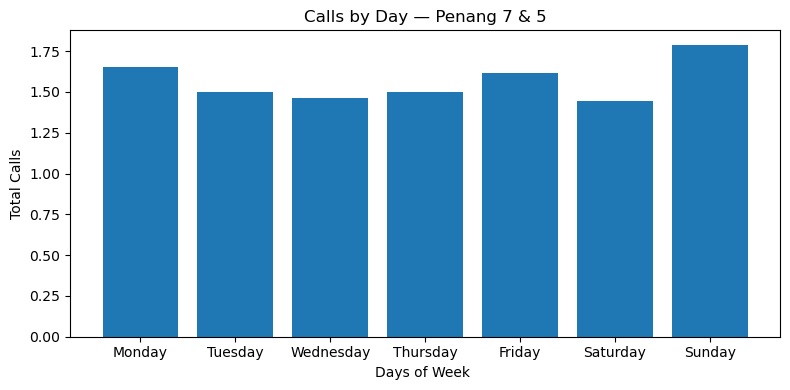

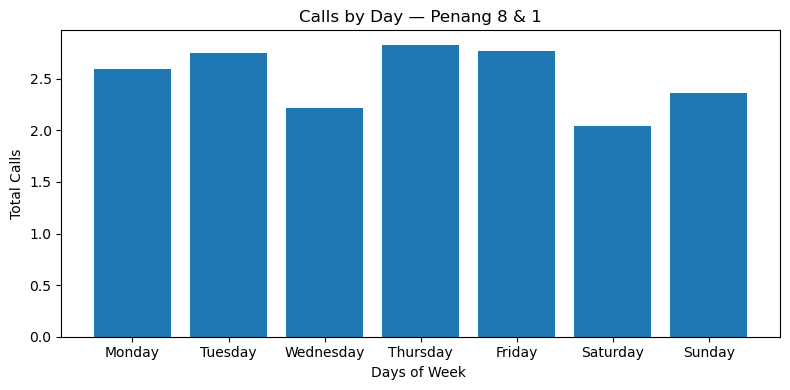

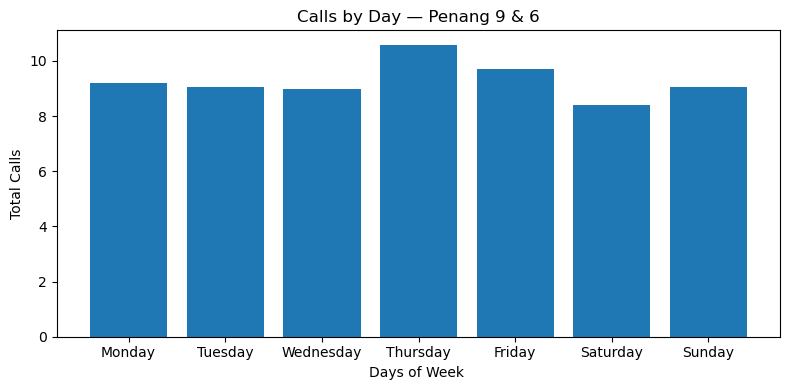

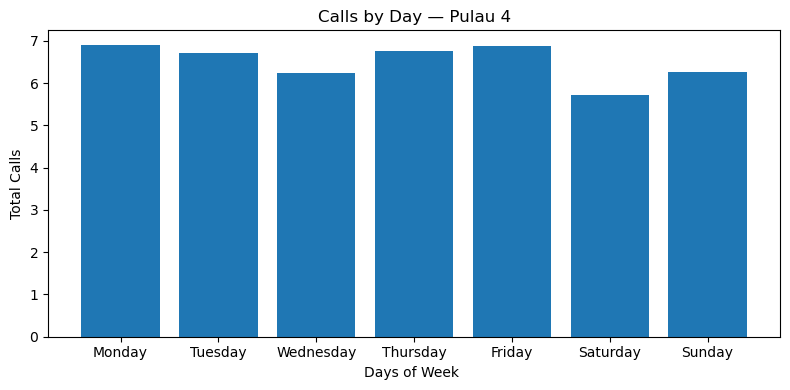

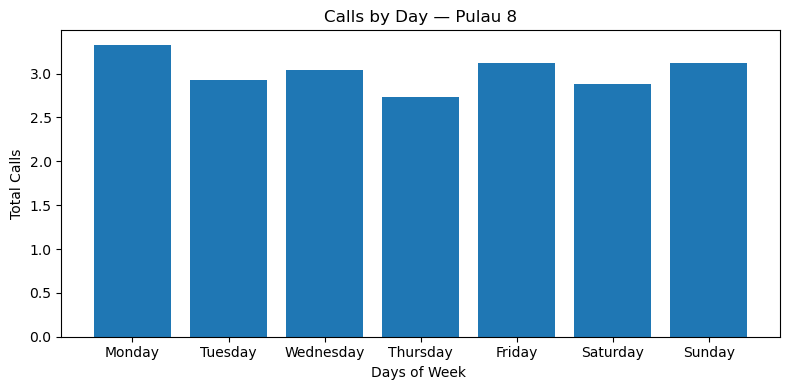

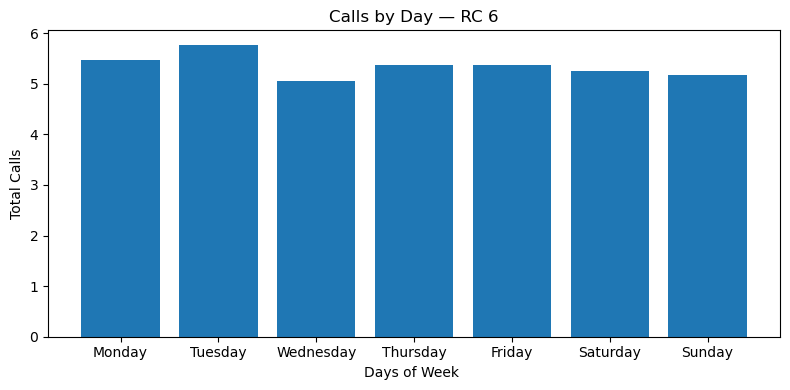

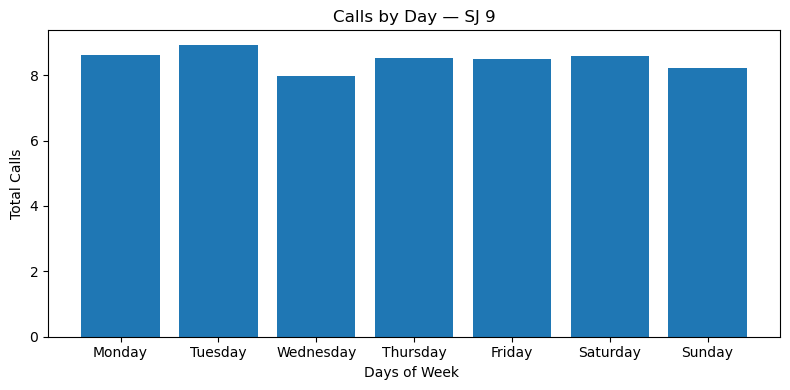

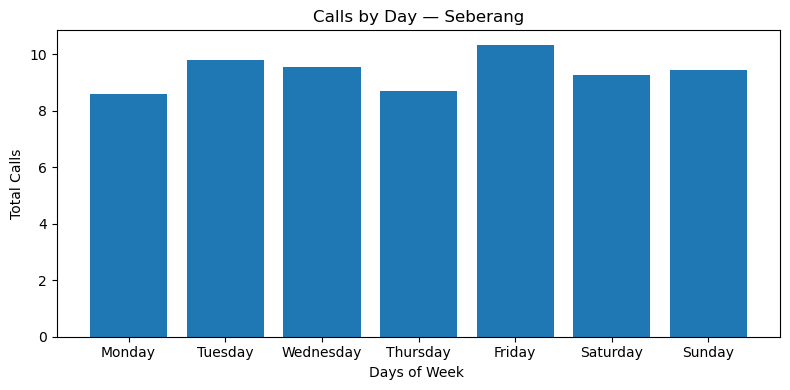

In [127]:
# set an order for the days of week
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

for call_sign, g in calls_by_day.groupby('assigned_call_sign'):
    g = (g.assign(days_of_week=pd.Categorical(g['days_of_week'], categories=order, ordered=True)).sort_values('days_of_week'))
    plt.figure(figsize=(8, 4))
    plt.bar(g['days_of_week'], g['calls_per_week'])
    plt.title(f'Calls by Day — {call_sign}')
    plt.xlabel('Days of Week ')
    plt.ylabel('Total Calls')
    # plt.xticks(range(0, 24))
    plt.tight_layout()
    # Show or save — pick one:
    plt.show()
    # plt.savefig(f'calls_by_hour_{call_sign}.png', dpi=150, bbox_inches='tight')
    plt.close()

#### Plot by total calls vs hours of day

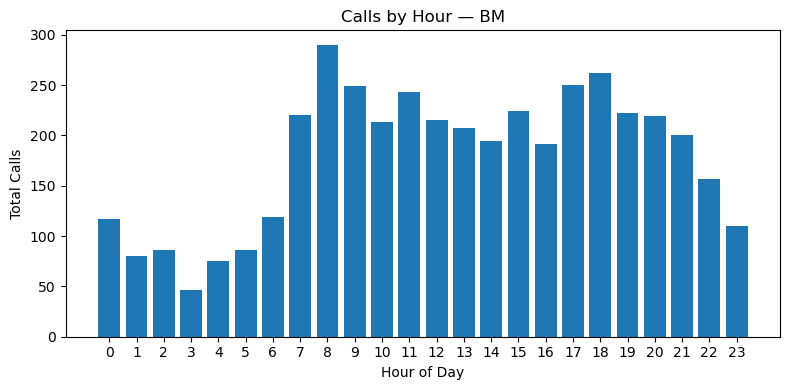

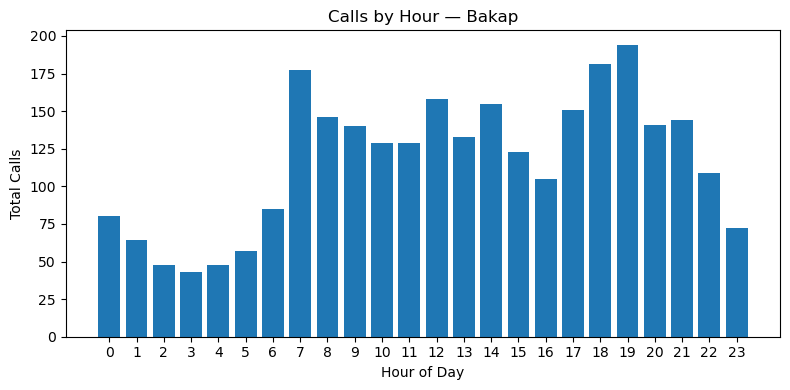

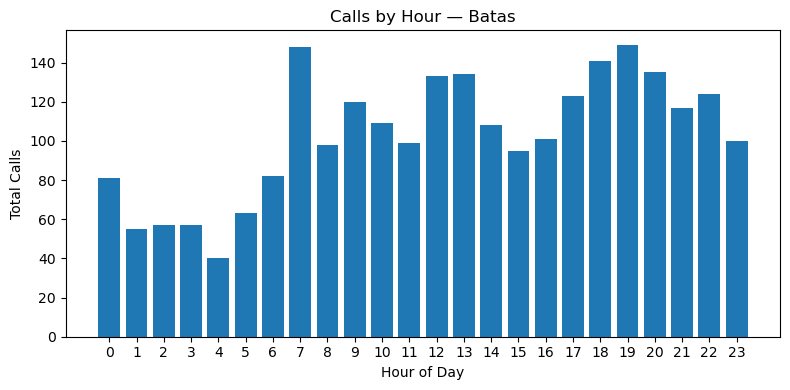

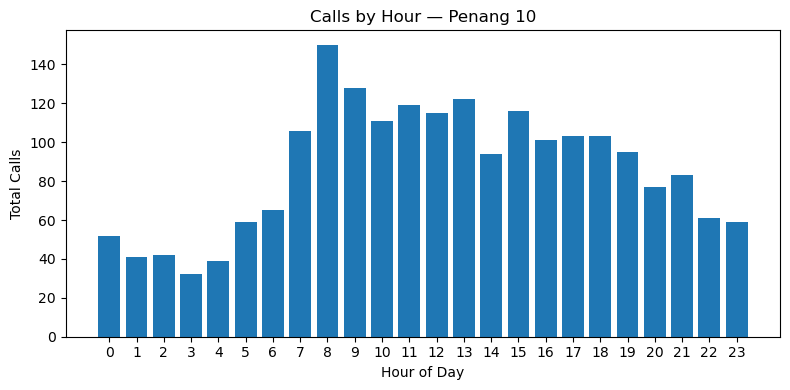

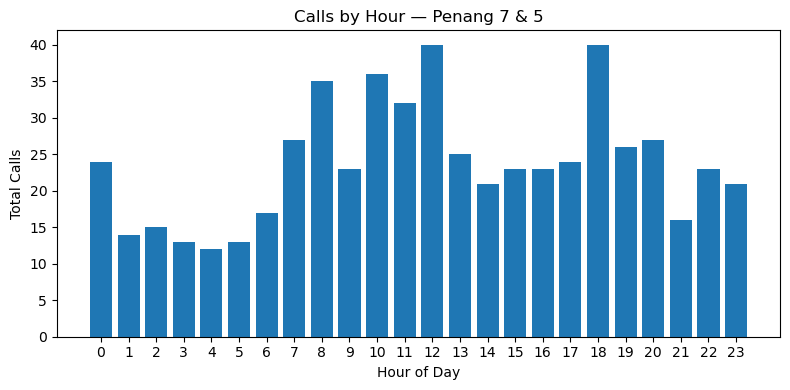

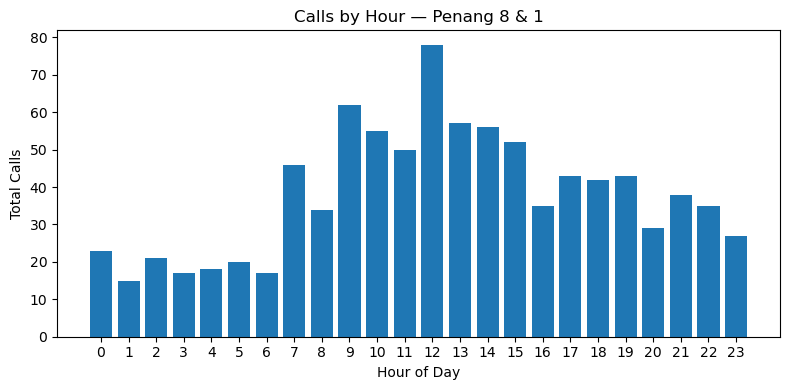

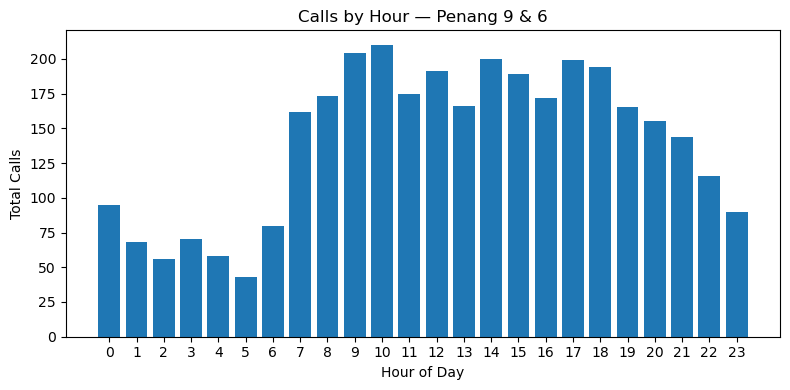

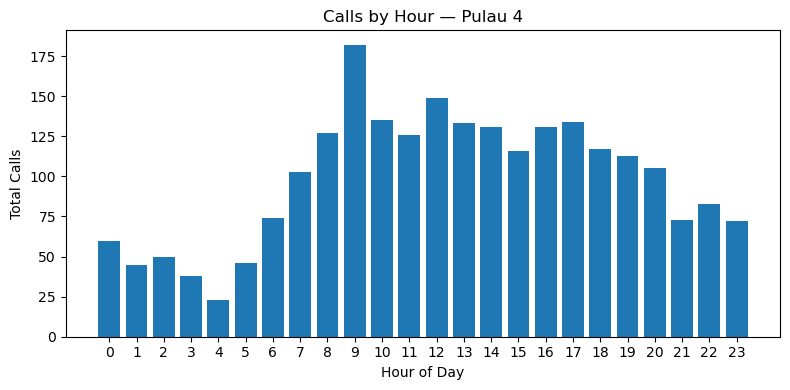

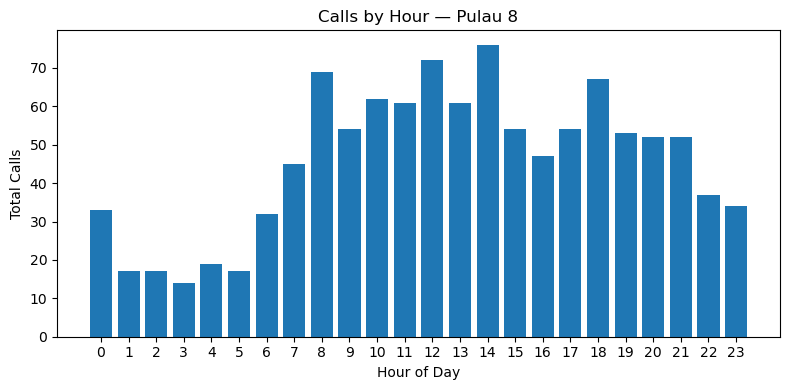

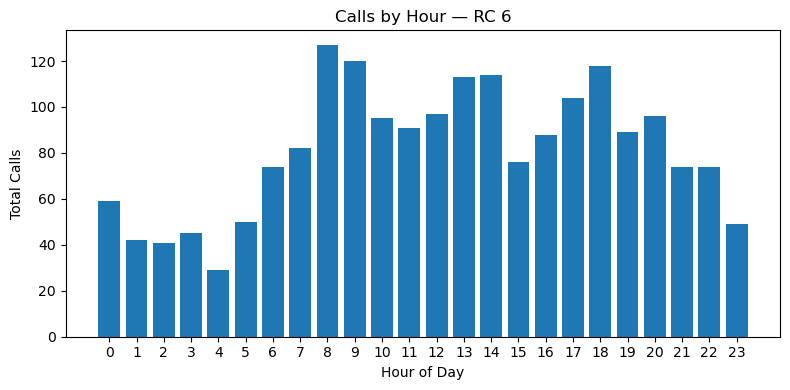

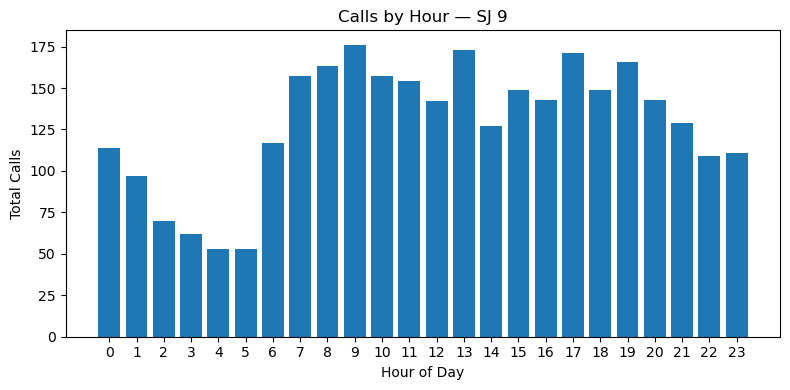

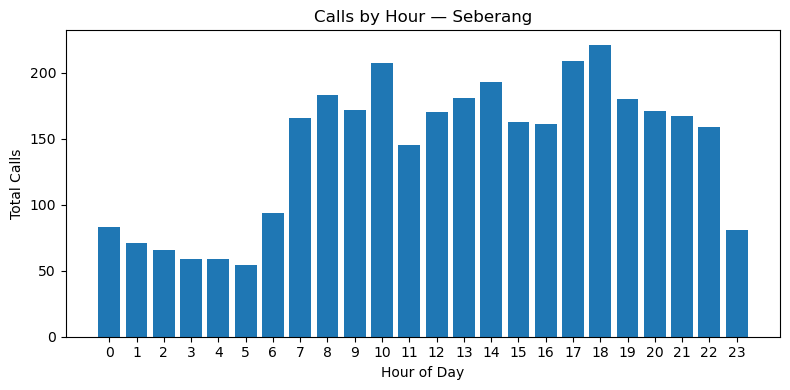

In [128]:
for call_sign, g in calls_by_hour.groupby('assigned_call_sign'):
    plt.figure(figsize=(8, 4))
    plt.bar(g['hour_of_day'], g['total_calls'])
    plt.title(f'Calls by Hour — {call_sign}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Total Calls')
    plt.xticks(range(0, 24))              # show all hours 0–23
    plt.tight_layout()
    # Show or save — pick one:
    plt.show()
    # plt.savefig(f'calls_by_hour_{call_sign}.png', dpi=150, bbox_inches='tight')
    plt.close()